# Simple Single Lens (with added Complexities) Time Forward (TFWD) simulation with MeepSAT

In the previous tutorial, we saw how we can define a Time-Reverse simulation for a simple single lens system with added complexities, extract the E, S and far field beam for a central pixel time-reverse simulation and change the shapes of the forebaffles to extract the useful quantitative and qualittative statement about our single lens system.

In this tutorial, we are going to see how we can do a time-forward simulation with the same system.


In [1]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json
import math

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

def run_simulation(data, source_freq, res, savepath_dir, runtime,
                   forebaffle_scaling_factor, forebaffle_spline_degree, forebaffle_spline_smoothing,
                   forebaffle_height=50, forebaffle_base=86.60, forebaffle_thickness=6,
                   forebaffle_absorber_thick=3, forebaffle_num_periods=1, 
                   forebaffle_amplitude=0, absorber_epsilon_r=5.4, absorber_epsilon_i=0.8, add_flair=True,
                   flair_angle= None, flair_hypotenuse=None, flair_num_periods=1, flair_amplitude=0):
    """
    Run a MEEPSAT simulation with configurable forebaffle parameters.
    
    Args:
        data: Simulation configuration dictionary
        source_freq: Source frequency
        res: Resolution
        savepath_dir: Output directory path
        runtime: Simulation runtime
        beam_waist: Beam waist width in mm
        forebaffle_height: Height of forebaffle in mm
        forebaffle_base: Base of forebaffle in mm
        forebaffle_thickness: Thickness of forebaffle in mm
        forebaffle_absorber_thick: Absorber thickness in mm
        forebaffle_num_periods: Number of periods for forebaffle shape
        forebaffle_amplitude: Amplitude for forebaffle shape modulation
        absorber_epsilon_r: Real part of absorber permittivity
        absorber_epsilon_i: Imaginary part of absorber permittivity
    
    Returns:
        simulation: Completed MEEP simulation object
        savepath: Path where results are saved
    """


    # Update parameters in data
    data["sources"]['source1']["frequecy"] = float(source_freq)
    data["simulation"]['primary_params']['resolution'] = int(res)
    data["output"]["savepath"]["path"] = str(Path(savepath_dir)) + "/"

    savepath = data["output"]["savepath"]["path"]
    os.makedirs(savepath, exist_ok=True)
    print('Output directory path:', savepath)
    
    # Initialize MEEPSAT Simulation
    cell_X = data["simulation"]['primary_params']['cell_size']['x']
    cell_Y = data["simulation"]['primary_params']['cell_size']['y']
    cell_Z = data["simulation"]['primary_params']['cell_size']['z']
    
    mpsat_sim = sim.sim_init(
        sim_name=str(data["simulation"]["name"]),
        cell_size=[cell_X, cell_Y, cell_Z],
        smallest_freq=data["simulation"]['primary_params']['smallest_freq'],
        resolution=data["simulation"]['primary_params']['resolution'],
        boundary_layer_type=data['boundary_layers']['boundary']['type'],
        boundary_layer_size=data['boundary_layers']['boundary']['size'],
        factor_dpml=data['boundary_layers']['boundary']['factor_dpml'])
    
    # # Check resolution and PML thickness
    # data, mpsat_sim = sim.check_resolution_and_pml(
    #     data=data,
    #     mpsat_sim=mpsat_sim,
    #     smallest_freq=data["simulation"]['primary_params']['smallest_freq'],
    #     highest_n=np.sqrt(5.4))
    
    mpsat_sim.print_simulation_parameters()
    
    # # Add sources
    # source_list = []
    # exec(json_to_script.source_script(data))
    
    # Add sources
    source_list = []
    local_vars = {
        'source_list': source_list,
        'data': data,
        'mp': mp,
        'mpsat_sim': mpsat_sim,
        'comp_meep': comp_meep,
        'np': np,
        'json_to_script': json_to_script
    }
    exec(json_to_script.source_script(data), globals(), local_vars)
    source_list = local_vars['source_list']
    print(f"Number of sources created: {len(source_list)}")
    if len(source_list) > 0:
        print(f"First source: {source_list[0]}")
    else:
        raise ValueError("WARNING: No sources were created!")
    
    # Add boundary layers
    x_left_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.Low)
    x_right_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.High)
    y_down_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.Low)
    y_up_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.High)
    
    custom_boundary_layers = [x_left_boundary, x_right_boundary, y_down_boundary, y_up_boundary]
    
    # Create epsilon map
    size_x, size_y, size_z = mpsat_sim.cell_size[0], mpsat_sim.cell_size[1], mpsat_sim.cell_size[2]
    res_int = int(mpsat_sim.resolution)
    epsilon_map = np.ones((int((size_x)*res_int+1), int((size_y)*res_int+1)), dtype=float)
    
    # Add absorbers (down and up)
    absorbers_down = comp_meep.Absorbers(
        p=6, p_h_ratio=1.5, taper_type='Linear',
        grid_size_sx=size_x, grid_size_sy=size_y, resolution=res_int,
        eps_array=epsilon_map, geometry_objects=[],
        z0=1, z1=1/math.sqrt(5.4),
        center_x_mm=0, center_y_mm=0, orientation="+y", angle_axis="x",
        substrate_thickness=[5, 53+50],
        substrate_material=[None, mp.perfect_electric_conductor],
        add_substrate=True,
        epsilon_r=5.4, epsilon_i=0.8,
        material_type='narrow_bandwidth_absorption',
        freq=data["sources"]['source1']["frequecy"],
        start_point=(-51, -40), end_point=(170, -40),
        overall_factor=1, plot_alpha=False, plot_profile=False,
        savepath=savepath, 
        plot_mesh=False)
    
    absorbers_up = comp_meep.Absorbers(
        p=6, p_h_ratio=1.5, taper_type='Linear',
        grid_size_sx=size_x, grid_size_sy=size_y, resolution=res_int,
        eps_array=epsilon_map, geometry_objects=[],
        z0=1, z1=1/math.sqrt(5.4),
        center_x_mm=0, center_y_mm=0, orientation="-y", angle_axis="x",
        substrate_thickness=[5, 53+50],
        substrate_material=[None, mp.perfect_electric_conductor],
        add_substrate=True,
        epsilon_r=5.4, epsilon_i=0.8,
        material_type='narrow_bandwidth_absorption',
        freq=data["sources"]['source1']["frequecy"],
        start_point=(-51, 40), end_point=(170, 40),
        overall_factor=1, plot_alpha=False, plot_profile=False,
        savepath=savepath, 
        plot_mesh=False)
    
    mpsat_sim.meep_geometry.extend(absorbers_up.assemble())
    mpsat_sim.meep_geometry.extend(absorbers_down.assemble())
    
    # Add lens, slab, and aperture
    exec(json_to_script.add_lens(data))
    exec(json_to_script.add_slab(data))
    exec(json_to_script.add_aperture(data))
    
    # Calculate forebaffle geometry parameters
    forebaffle_hypotenuse = np.sqrt(forebaffle_height**2 + forebaffle_base**2)
    forebaffle_angle = np.degrees(np.arctan(forebaffle_height / forebaffle_base))
    
    print(f"Forebaffle Geometry Parameters:")
    print(f"Height: {forebaffle_height} mm")
    print(f"Base: {forebaffle_base} mm")
    print(f"Hypotenuse: {forebaffle_hypotenuse:.2f} mm")
    print(f"Angle: {forebaffle_angle:.2f} degrees")
    
    # Bottom Forebaffle
    x_start_bottom, y_start_bottom = -48.4+3, -41-5
    
    fb_bottom = comp_meep.Forebaffle(
        mpsat_sim=mpsat_sim,
        epsilon_map=epsilon_map,
        angle_degrees=180+forebaffle_angle,
        x_vertex=x_start_bottom,
        y_vertex=y_start_bottom,
        hypotenuse=forebaffle_hypotenuse,
        material=mp.perfect_electric_conductor,
        name="Bottom Forebaffle",
        shape='spline',
        num_periods=forebaffle_num_periods,
        amplitude=forebaffle_amplitude,
        no_of_points=500,
        scaling_factor=3,
        spline_degree=3,
        spline_smoothing=1,
        fb_thickness=forebaffle_thickness,
        add_absorber=True,
        absorber_side='above',
        absorber_epsilon_real=absorber_epsilon_r,
        absorber_epsilon_imag=absorber_epsilon_i,
        absorber_thickness=forebaffle_absorber_thick)
    
    mpsat_sim.meep_geometry.extend(fb_bottom.assemble())
    
    # Top Forebaffle
    x_start_top, y_start_top = -48.4+3, 41+5
    
    fb_top = comp_meep.Forebaffle(
        mpsat_sim=mpsat_sim,
        epsilon_map=epsilon_map,
        angle_degrees=180-forebaffle_angle,
        x_vertex=x_start_top,
        y_vertex=y_start_top,
        hypotenuse=forebaffle_hypotenuse,
        material=mp.perfect_electric_conductor,
        name="Top Forebaffle",
        shape='spline',
        num_periods=forebaffle_num_periods,
        amplitude=forebaffle_amplitude,
        no_of_points=500,
        scaling_factor=3,
        spline_degree=3,
        spline_smoothing=1,
        fb_thickness=forebaffle_thickness,
        add_absorber=True,
        absorber_side='below',
        absorber_epsilon_real=absorber_epsilon_r,
        absorber_epsilon_imag=absorber_epsilon_i,
        absorber_thickness=forebaffle_absorber_thick)
    
    mpsat_sim.meep_geometry.extend(fb_top.assemble())
    
    simulation = mp.Simulation(
        cell_size=mpsat_sim.cell,
        sources=source_list,
        resolution=mpsat_sim.resolution,
        boundary_layers=custom_boundary_layers,
        geometry=mpsat_sim.meep_geometry,
        epsilon_input_file=data["output"]["savepath"]["path"] + data["output"]["epsilon_h5_file"]["filename"] + "_epsilon_map" + ".h5",
        force_complex_fields=True)
    
    simulation.use_output_directory(savepath)
    
    import matplotlib.pyplot as plt
    plt.style.use('default')
    # Plot and save epsilon
    sim.plot_and_save_epsilon(
        simulation=simulation,
        savepath=savepath,
        filename_prefix="geometry_plot",
        epsilon_data_name="epsilon",
        size_x=size_x,
        size_y=size_y,
        vmin=0.5,
        vmax=3,
        cmap='viridis',
        figsize=(8, 4),
        dpi=300)
    
    # Set stepfunctions parameters
    stepfunctions.set_animation_params(anim_params={
        'image_every': data["output"]["animation_options"]["image_every"],
        'Nfps': data["output"]["animation_options"]["Nfps"],
        'anim_file_name': savepath + "/" + data["output"]["animation_options"]["movie_name"] + ".mp4"})
    
    stepfunctions.set_field_params(field_params={
        'size_x': size_x,
        'size_y': size_y,
        'savepath': savepath,
        'downsampling_factor_x': data["output"]["animation_options"]["downsample_x"],
        'downsampling_factor_y': data["output"]["animation_options"]["downsample_y"]})
    
    # runtime_params = sim.calculate_runtime_parameters(
    #     source_freq=float(data["sources"]["source1"]["frequecy"]),
    #     total_time=runtime,
    #     animation_timestep=data["output"]["animation_options"]["image_every"],
    #     points_per_period=10,
    #     extraction_offset=10)
    
    runtime_params = sim.calculate_runtime_parameters(
        source_freq=float(data["sources"]["source1"]["frequecy"]),
        resolution= mpsat_sim.resolution,
        steady_state_time = runtime,
        courant=simulation.Courant,
        min_periods_for_steady_state=10,
        periods_to_average=4,
        points_per_period=10,
        animation_timestep=data["output"]["animation_options"]["image_every"])
    
    # Run simulation
    simulation.run(
        mp.at_every(runtime_params["animation_timestep"], stepfunctions.Ez2_dB),
        mp.after_time(runtime_params["t0"], mp.at_every(runtime_params["dt"], stepfunctions.accumulate_efield_and_hfield)),
        mp.at_end(stepfunctions.save_animation),
        mp.at_end(stepfunctions.save_accumulated_fields),
        mp.at_end(stepfunctions.extract_xyzw),
        until=runtime_params["total_time"])
    
    print("Simulation completed.")
    
    # Save final JSON data
    with open(data["output"]["savepath"]["path"] + data["simulation"]["name"] + "_simulation_data.json", "w") as f:
        json.dump(data, f, indent=2)
    print(f"Simulation parameters saved to: {data['output']['savepath']['path']}{data['simulation']['name']}_simulation_data.json")



Using MPI version 4.1, 1 processes


In [2]:
json_file_path = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TFWD/simple_single_lens_AddedComplexities_TFWD_b_edgepix.json'
data = mpsat_helpers.read_json(json_file_path)

# Some universal constants
c_mm_s = 299792458.0 * 1000.0  # Speed of light in mm/s (m/s -> mm/s)
# Frequency of the simulation
freq = 150.0  # Frequency in GHz
a = 1  # 1 meep unit = 1 mm  
wvl = c_mm_s / (freq * 1e9)  # Wavelength in mm
freq_meep = 1.0 / (wvl * a)
print("freq (meep units):", freq_meep)
freq = freq_meep

# Resolution
res = 4
# runtime
runtime = 600

# Angle of the plane wave source (in degrees)
angle = 5  # Angle in degrees

# Savepath
savepath_dir = f'auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/{freq}GHz'

# Define multiple forebaffle configurations
forebaffle_configs = [
    # Spline config_0
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 2, "forebaffle_amplitude": 2, "forebaffle_spline_smoothing": 1}#,
    # # Curved config_1
    # {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 0.4, "forebaffle_amplitude": 5, "forebaffle_spline_smoothing": 1},
    # # Linear config_2
    # {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 1, "forebaffle_amplitude": 0, "forebaffle_spline_smoothing": 1},
]

# Run simulations
for i, config in enumerate(forebaffle_configs):
    print(f"\n{'='*50}")
    print(f"Running simulation {i+1}/{len(forebaffle_configs)}")
    print(f"{'='*50}\n")
    
    # Create a copy of data for each simulation
    sim_data = json.loads(json.dumps(data))
    sim_data["simulation"]["name"] += f"_config_{i}"
    
    # Change the angle of the plane wave source for each simulation
    sim_data["sources"]['source1']['extra_args']["angle"] = angle  # Set the
    
    output_path = f"{savepath_dir}/config_{i}"
    sim_data["output"]["savepath"]["path"] = output_path + "/" 
    # Create the output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    

    run_simulation(
        data=sim_data,
        source_freq=freq,
        res=res,
        savepath_dir=output_path,
        runtime=runtime,
        **config)

freq (meep units): 0.5003461427972281

Running simulation 1/1

Output directory path: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/
Simulation name: simple_single_lens_AddedComplexities_TFWD_b_config_0
Cell size: [334.4, 254.4, 0]
Frequency: 0.25
Wavelength: 4.0
Resolution: 4
Boundary layer type: PML
Boundary layer size: 2.2
Factor for PML boundary layer thickness: 2
Angle of the source:0.08726646259971647 rad = 5 degrees
Source object created with the following parameters:
Center:  Vector3<-150.0, 0.0, 0.0>
Size:  Vector3<0.0, 250.0, 0.0>
Component:  4
Frequency:  0.5003461427972281
Wavelength:  1.9986163866666664
Angle:  0.08726646259971647
Rotation axis:  x
Additional arguments:  {'is_integrated': True, 'start_time': 0, 'end_time': 1e+20}
Additional arguments for the Source:  {}
Additional arguments for the ContinuousSource:  {'start_time': 0, 'end_time': 1e+20, 'is_integrated': True}
Continuous plane waves

HDF5 file written to /Users/asheshak_oaslak/Phd_work/MeepSAT/examples/auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/simple_single_lens_AddedComplexities_TFWD_b_epsilon_map.h5
Aperture stop created with orientation: vertical
type material:  Medium()
Aperture stop created (vertical): Up size=Vector3<1.0, 102.2, 0.0>, Down size=Vector3<1.0, 102.2, 0.0>
Centers: Up=Vector3<2.1, 76.1, 0.0>, Down=Vector3<2.1, -76.1, 0.0>
<meep.geom.Block object at 0x312f7e450> added to the list of components created using the MEEP functions!
<meep.geom.Block object at 0x312f7e250> added to the list of components created using the MEEP functions!
Aperture stop created with orientation: vertical
type material:  Medium()
Aperture stop created (vertical): Up size=Vector3<1.0, 102.2, 0.0>, Down size=Vector3<1.0, 102.2, 0.0>
Centers: Up=Vector3<14.1, 76.1, 0.0>, Down=Vector3<14.1, -76.1, 0.0>
<meep.geom.Block object at 0x312f7e350> added t

FloatProgress(value=0.0, description='0% done ', max=0.0)

run 0 finished at t = 0.0 (0 timesteps)
Epsilon plot saved to: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/geometry_plot.png
Epsilon data saved to: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/geometry_plot.h5
Field extraction parameters set:
  size_x: 334.4
  size_y: 254.4
  savepath: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/
  downsampling_factor_x: 1
  downsampling_factor_y: 1
Validated MEEP Runtime Parameters:
  Wave Period:                 1.9986 time units
  MEEP Internal Timestep:      0.125000 time units
  Snapped Sampling Step (dt):  0.250000 time units (Every 2 FDTD steps)
  Actual Points Per Period:    7.99
  Steady State Delay (t0):     600.0000 time units
  Total Run Time (total_time): 607.9945 time units
  Extraction Window Size:      7.994

FloatProgress(value=0.0, description='0% done ', max=607.9944655466667)

Ez^2 field data extraction...
Using disk cache for frames at: /var/folders/q3/13t5tnwx5dnb9qb5fsqv51tc0000gn/T/meep_anim_8i948zkg
Initializing Ez^2 animation object with disk caching...
Time step: 25.0
Creating frame for Ez^2 field at time 25.0...
Frame saved to disk at timestep: 25.0 (file: /var/folders/q3/13t5tnwx5dnb9qb5fsqv51tc0000gn/T/meep_anim_8i948zkg/frame_000000.png)
Meep progress: 37.75/607.9944655466667 = 6.2% done in 4.0s, 60.5s to go
on time step 302 (time=37.75), 0.013249 s/step
Ez^2 field data extraction...
Time step: 50.0
Creating frame for Ez^2 field at time 50.0...
Frame saved to disk at timestep: 50.0 (file: /var/folders/q3/13t5tnwx5dnb9qb5fsqv51tc0000gn/T/meep_anim_8i948zkg/frame_000001.png)
Meep progress: 74.0/607.9944655466667 = 12.2% done in 8.0s, 57.8s to go
on time step 592 (time=74), 0.0137996 s/step
Ez^2 field data extraction...
Time step: 75.0
Creating frame for Ez^2 field at time 75.0...
Frame saved to disk at timestep: 75.0 (file: /var/folders/q3/13t5tnwx5

Now let's compare the E and S time-avg maps of the different configurations and plot it on a single graph!

In [ ]:
# ===== FOCAL PLATE ANALYSIS FUNCTIONS =====
def find_focal_plane_from_2D_array(data_2d, xyzw_data, axis, range):
    """
    Find the focal plane position (index) in a 2D array by locating the maximum value along the specified axis.
    
    Args:
        data_2d: 2D numpy array (e.g., efield power or S magnitude in linear scale preferably)
        xyzw_data: Dictionary containing coordinate arrays for 'x_coords', 'y_coords', 'z_coords'
        axis: Axis along which to find the focal plane ('x', 'y')
        range: Tuple specifying the range (min, max) in real units to search for the focal plane
    """
    # Filter the xyzw data and data_2d based on the specified range
    if axis == 'x':
        # Create a mask for the specified range
        mask = (xyzw_data['x_coords'] >= range[0]) & (xyzw_data['x_coords'] <= range[1])
        # FIX: data_2d is (x, y) so mask along first dimension
        filtered_data_2d = data_2d[mask, :]
    elif axis == 'y':
        mask = (xyzw_data['y_coords'] >= range[0]) & (xyzw_data['y_coords'] <= range[1])
        # FIX: data_2d is (x, y) so mask along second dimension
        filtered_data_2d = data_2d[:, mask]
    else:
        raise ValueError("Axis must be 'x' or 'y' for 2D data.")

    # Find the index of the maximum value in the filtered data
    max_power_index = np.unravel_index(np.argmax(filtered_data_2d, axis=None), filtered_data_2d.shape)
    # Focal point value
    focal_point_value = filtered_data_2d[max_power_index]
    # 2D coords of the focal point
    if axis == 'x':
        # FIX: Update indexing to match (x, y) layout
        focal_x_index = np.where(mask)[0][max_power_index[0]]
        focal_y_index = max_power_index[1]
    else:  # axis == 'y'
        focal_x_index = max_power_index[0]
        focal_y_index = np.where(mask)[0][max_power_index[1]]
    
    # Convert indices to real units
    focal_x_real = xyzw_data['x_coords'][focal_x_index]
    focal_y_real = xyzw_data['y_coords'][focal_y_index]

    # Extract the variation of focal plane power along the y axis
    focal_plane_ycoords = xyzw_data['y_coords']
    focal_plane_power_along_y = data_2d[focal_x_index, :]

    print(f"Focal point found at (X: {focal_x_real:.2f} mm, Y: {focal_y_real:.2f} mm) with value: {focal_point_value:.2f}")

    return (focal_x_real, focal_y_real), focal_point_value, focal_plane_ycoords, focal_plane_power_along_y




Analysing simulation 1/1

Loading fields from: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/efield_timeavg.npz
Loading fields from: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/hfield_timeavg.npz
Loading fields from: auxilary_data/02_simple_single_lens_AddedComplexities_b_edgepix/TFWD/noflairs/output_files/0.5003461427972281GHz/config_0/xyzw.npz
E-field data keys: ['ex_real', 'ex_imag', 'ey_real', 'ey_imag', 'ez_real', 'ez_imag', 'count']
H-field data keys: ['hx_real', 'hx_imag', 'hy_real', 'hy_imag', 'hz_real', 'hz_imag', 'count']
XYZW data keys: ['x_coords', 'y_coords', 'weights']
Focal point found at (X: 104.88 mm, Y: 8.12 mm) with value: 0.00
Focal point for config_0: (np.float64(104.875), np.float64(8.125)), Focal value: 0.00


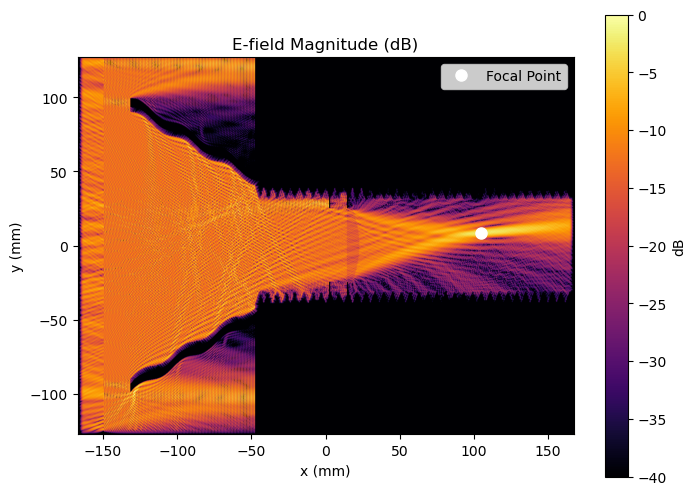

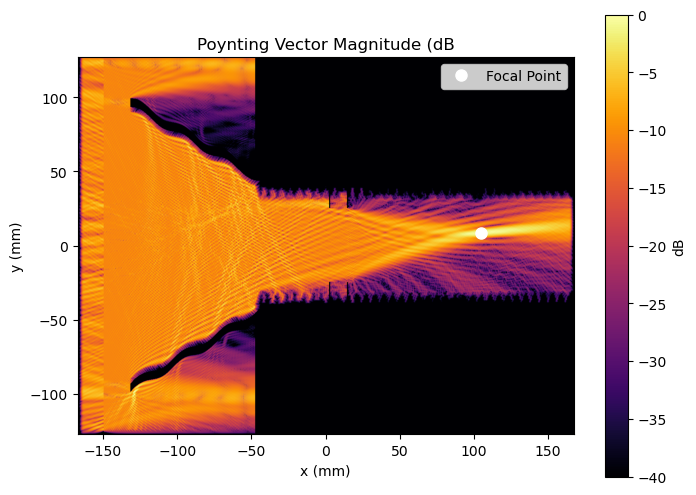

In [4]:
for i, config in enumerate(forebaffle_configs):
    print(f"\n{'='*50}")
    print(f"Analysing simulation {i+1}/{len(forebaffle_configs)}")
    print(f"{'='*50}\n")
    
    # Create a copy of data for each simulation
    sim_data = json.loads(json.dumps(data))
    sim_data["simulation"]["name"] += f"_config_{i}"
    
    savepath = f"{savepath_dir}/config_{i}"

    
    # For plotting the E and S time avg fields
    import numpy as np
    import os
    import matplotlib.pyplot as plt

    def load_fields(basepath, filename):
        # Construct the full path to the file
        filepath = os.path.join(basepath, filename)
        print(f"Loading fields from: {filepath}")
        # Load the fields stored in npz files
        data = np.load(filepath)

        return data

    basepath = os.path.join(savepath)
    e_filename = 'efield_timeavg.npz'
    h_filename = 'hfield_timeavg.npz'
    xyzw_filename = 'xyzw.npz'
    e_data = load_fields(basepath, e_filename)
    h_data = load_fields(basepath, h_filename)
    xyzw_data = load_fields(basepath, xyzw_filename)
    print("E-field data keys:", e_data.files)
    print("H-field data keys:", h_data.files)
    print("XYZW data keys:", xyzw_data.files)


    # TE component (Ez, Hx, Hy)
    ez = e_data['ez_real'] + 1j * e_data['ez_imag']
    hx = h_data['hx_real'] + 1j * h_data['hx_imag']
    hy = h_data['hy_real'] + 1j * h_data['hy_imag']

    # S vector components for TE mode
    sx = -ez * np.conj(hy)
    sy = ez * np.conj(hx)
    sx_mag = np.abs(sx)
    sy_mag = np.abs(sy)
    s_total = np.sqrt(sx_mag**2 + sy_mag**2)
    s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)  # in dB
    # efield magnitude
    ez_power = np.abs(ez)**2
    ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)  # in dB

     
    def plot_field(simname, field_db, title, filename, xcoords, ycoords, freq,
                vmin=-40, vmax=0, point_of_interest=None,
                savepath= None,#os.path.join('./../processed_data/'),
                    show_plots=True):
        import matplotlib.pyplot as plt
        plt.style.use('default')
        
        plt.figure(figsize=(8, 6))
        plt.imshow(field_db.T, extent=(xcoords[0], xcoords[-1], ycoords[0], ycoords[-1]),
                origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
        plt.colorbar(label='dB')
        plt.title(title)
        plt.xlabel('x (mm)')
        plt.ylabel('y (mm)')
        
        if point_of_interest:
            plt.plot(point_of_interest[0], point_of_interest[1], 'wo', markersize=8, label='Focal Point')
            plt.legend()

        if savepath:
            # Create directory with simname and frequency subdirectories
            save_dir = os.path.join(savepath, simname, f'{freq}GHz')
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(os.path.join(save_dir, filename), dpi=300)
            # Save as a svg file as well for publication
            plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
            print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
        if show_plots:
            plt.show()

    # # Find focus point
    focal_point, focal_value, focal_plane_ycoords, focal_plane_power_along_y = find_focal_plane_from_2D_array(
        data_2d=ez_power,
        xyzw_data=xyzw_data,
        axis='x',
        range=(100, 150))  # Adjust the range as needed
    
    print(f"Focal point for config_{i}: {focal_point}, Focal value: {focal_value:.2f}")

    # E-field plot
    plot_field(simname = 'simple_single_lens_AddedComplexities_TFWD_b_edgepix_config_{}'.format(i), 
                field_db=ez_power_db, 
                title='E-field Magnitude (dB)', 
                filename='ez_magnitude_db.png', 
                xcoords=xyzw_data['x_coords'], 
                ycoords=xyzw_data['y_coords'],
                freq=freq, 
                point_of_interest=focal_point)
    # S-vector plot
    plot_field(simname = 'simple_single_lens_AddedComplexities_TFWD_b_edgepix_config_{}'.format(i), 
                field_db= s_total_db, 
                title='Poynting Vector Magnitude (dB', 
                filename='s_magnitude_db.png', 
                xcoords=xyzw_data['x_coords'], 
                ycoords=xyzw_data['y_coords'],
                freq=freq,
                point_of_interest=focal_point)
    


This is quite amazing right? We can clearly see how the fields are getting distributed in the telescope based on the forebaffle configuration and a whole lot of things can be done with this information.

In the next tutorial, we will see how to combine these time-forward simulations with time-reverse to extract useful information about the systematics in our telescope.